---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Tools and Techniques for Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<h1 align="center">Lecture 6.21 (Logistic Regression: Part-II)</h1>

<a href="https://colab.research.google.com/github/arifpucit/data-science/blob/master/Section-4-Mathematics-for-Data-Science/Lec-4.1(Descriptive-Statistics).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <img align="center" width="900" src="images/ml-topimg1.png"  >

# Learning agenda of this notebook

- Logistic Regression using Single Layer Perceptron (Recap)
- Loss/Cost Function for Logistic Regression
    - How to Choose a best model out of many?
    - Output of Sigmoid Function is Probability
    - Choosing Best Model using Maximum Liklihood Estimate
    - Choosing Best Model using Binary Cross Entropy
    - Loss/Error Function for Logistic Regression (Cross-Entropy Loss)
- Gradient Descent for Logistic Regression
    - Cross-Entropy Loss Function
    - Minimizing Cross-Entropy Loss Function using Gradient Descent Algorithm
    - Derivative of Sigmoid Function
    - Derivative of Cross-Entropy-Loss or Log-Loss Function
    
- Python Code for Logistic Regression using Gradient Descent
    - **Sample Code:**

- Logistic Regression using Scikit-Learn Model   
    - **Sample Code:**

- A Comparison between the two

#  1. Logistic Regression using Single Layer Perceptron (Recap)

<img align="center" width="1400" src="images/logi12b.png"  > 

**Test your Concept 1:**<br>
- Consider a perceptron with two `inputs` (x1 and x2), `weights` (w1 and w2), and bias (w0). Calculate the weighted sum $z$ and then apply the `step`, and `sigmoid` activation function to calculate $\hat y$ for the following dataset:
    - x1 = 0, x2 = 1, w1 = 0.5, w2 = -0.5, w0 = 0.2
    - x1 = 1, x2 = 0, w1 = -0.4, w2 = 0.6, w0 = -0.1

**Test your Concept 2:**<br>
- Consider a following simplified dataset having four observations with two input features and a binary ground label.

| x1  | x2 | y  |
|-----|----|----|
| 9   | 7  | 0  |
| 4   | 3  | 1  |
| 5   | 2  | 1  |
| 2   | 4  | 1  |


- Since the ground label of $1^{st}$ observation/datapoint is zero: 
$$\sigma(z)\lt 0.5 \implies z \lt 0 \implies w_0+9w_1+7w_2 \lt 0 $$

- Since the ground label of $2^{nd}$ observation/datapoint is one: 
$$\sigma(z)\ge 0.5 \implies z \ge 0 \implies w_0+4w_1+3w_2  \ge0 $$

- Since the ground label of $3^{rd}$ observation/datapoint is one: 
$$\sigma(z)\ge 0.5 \implies z \ge 0 \implies w_0+5w_1+2w_2  \ge0 $$

- Since the ground label of $4^{th}$ observation/datapoint is one: 
$$\sigma(z)\ge 0.5 \implies z \ge 0 \implies w_0+2w_1+4w_2  \ge0 $$


Solve the above inequalities and calculate some possible values for $w_0$, $w_1$, and $w_2$

**Why to Keep the threshold value to** $0.5$?
- Changing the threshold can also affect the overall performance of the model. For example, if the threshold is set `too low`, the model may classify too many inputs as belonging to the `positive class`, leading to a high `False Positive` rate. On the other hand, if the threshold is set `too high`, the model may classify too many inputs as belonging to the `negative class`, leading to a high `False Negative` rate.

- In general, the optimal value of the threshold will depend on the specific problem we are trying to solve and the trade-off we are willing to make between false positives and false negatives. It is generally a good idea to experiment with different threshold values and evaluate the performance of the model in order to find the best value for our specific problem.


- Question: `How to choose the optimal threshold for a given model?`
- The most common method for classification threshold selection is plotting the `ROC curve`.

# 2. Loss/Cost Function for Logistic Regression

## a. Choose the best model
<img align="center" width="800" src="images/logi14a.png"  > 

## b. Choose the best model
<img align="center" width="800" src="images/logi15a.png"  > 


## c. Output of Sigmoid Function is Probability

<img align="center" width="700" src="images/log18.png"  >  

<img align="center" width="800" src="images/logi17a.png"  >

>- There is 80% chance of data point 1 of belonging to Positive Class, and 20% chance of belonging to Negative Class
>- There is 90% chance of data point 2 of belonging to Positive Class, and 10% chance of belonging to Negative Class
>- There is 75% chance of data point 3 of belonging to Negative Class, and 25% chance of belonging to Positive Class
>- There is 80% chance of data point 4 of belonging to Negative Class, and 20% chance of belonging to Positive Class

## d. Choosing Best Model using Maximum Liklihood Estimate
<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px"> Maximum Liklihood Estimation is a technique used for estimating the parameters of a given probability distribution, using some observed data. </h3>
        
<img align="center" width="1200" src="images/logi16c.png"  > 

>- Model having higher MLE is better (We maximize in case of maximum liklihood)

**Limitation:** We need to compute product of very small numbers, and for a large dataset there will be thousands of datapoints in which case we have to take the product of thousands of very small numbers, which will be a very very small value. Moreover, comparison of two such very small numbers is pointless.

**Solution:** Convert this product into summation

## e. Choosing Best Model using Binary Cross Entropy
<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px"> The summation of negative logs of maximum liklihood is called cross entropy. </h3>
    
<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px"> Maximizing likelihood is equivalent to minimizing cross entropy. </h3>
    
**Binary Cross Entropy for Model 1:**<br>
$ \hspace{1cm}\text{log(MLE)} \hspace{0.5cm}=\hspace{0.5cm} \text{log}(0.35) + \text{log}(0.8) + \text{log}(0.7) + \text{log}(0.4) \hspace{0.5cm}=\hspace{0.5cm}   (-1.049)+(-0.223)+(-0.356)+(-0.916)  \hspace{0.5cm}=\hspace{0.5cm}   -2.5459$<br>
- Since the log of any number between 0 and 1 is negative, so to make the result positive, we take summation of negative logarithms
    
$ \hspace{1cm}-\text{log(MLE)} \hspace{0.5cm}=\hspace{0.5cm} -\text{log}(0.35) - \text{log}(0.8) - \text{log}(0.7) - \text{log}(0.4)  \hspace{0.5cm}=\hspace{0.5cm} 2.5459$<br>

<br><br> 
**Binary Cross Entropy for Model 2:**<br>
$ \hspace{2cm}\text{log(MLE)} \hspace{0.5cm}=\hspace{0.5cm} \text{log}(0.75) + \text{log}(0.8) + \text{log}(0.8) + \text{log}(0.9)\hspace{0.5cm}=\hspace{0.5cm}   (-0.2876)+(-0.223)+(-0.223)+(-0.1053) \hspace{0.5cm}=\hspace{0.5cm} 0.839$<br>
- Since the log of any number between 0 and 1 is negative, so to make the result positive, we take summation of negative logarithms
    
$ \hspace{2cm}-\text{log(MLE)} \hspace{0.5cm}=\hspace{0.5cm} -\text{log}(0.75) - \text{log}(0.8) - \text{log}(0.7) - \text{log}(0.7)\hspace{0.5cm}=\hspace{0.5cm} 0.839$<br>
<br>
    
>- Model having lower Cross Entropy is better (We minimize in case of cross entropy)

>- In maximum liklihood we select the model having largest value, i.e, we maximize.
>- In cross entropy we select the model having smallest value, i.e, we minimize.

## f. Loss/Error Function for Logistic Regression (Cross-Entropy Loss)
<img align="right" width="500" src="images/log19a.png"  > 

- The cost function summarizes how well the model is performing, i.e., how close the model’s predictions are to the actual outputs. 
- In linear regression, we use mean squared error (MSE) as the cost function. 
$$ J(\beta) = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y_i})^2 = \frac{1}{n}\sum_{i=1}^n (y_i - (\beta_0 + \sum_{i=1}^m \beta_i x_i))^2$$
- In logistic regression, since $\large \hat{y} = \sigma\small(wx))$, so using MSE as loss function for logistic regression might give a wavy, non-convex graph; containing many local optima. Thus, finding an optimal solution with the gradient descent method is not possible.
- Therefore, we use a logarithmic function to represent the cost of logistic regression. It is guaranteed to be convex for all input values, containing only one minimum, allowing us to run the gradient descent algorithm.
- When dealing with a binary classification problem, the logarithmic cost of error depends on the value of y. We can define the cost for two cases separately:
$$\large \text{Loss} (\hat{y}, y)  \hspace{.5cm}=\hspace{.5cm} \begin{cases}
-log(\hat{y}) ,  & \text{if}\ \quad  y = 1 \\
-log(1-\hat{y}), & \text{if}\ \quad  y =0 
\end{cases}$$


$\hspace{1.4cm} \large \text{Loss}(\hat{y}, y)   \hspace{.5cm}=\hspace{.5cm} - y \text{log}\hat{y}  - (1 - y) \text{log}(1 - \hat{y})\hspace{3cm}$

For `n` observations, we can calculate the cost as:

<font face = "Courier New" color=green size=5>$$ \hspace{3cm}\text{J(w)} \hspace{0.5cm}=\hspace{0.5cm} - \frac{1}{n} \sum_{i=1}^n \biggr[y_i \text{log}\hat{y}_i  + (1 - y_i) \text{log}(1 - \hat{y}_i)\biggr]$$</font>
- When the observation belong to class 1, the second term of this formula becomes zero, else first becomes zero.
>- **Now we need to find out the values of weights for which this function gives us the minimum error**

# 3. Gradient Descent for Logistic Regression
<center><font face = "Garamond" color=red size=4><div class="alert alert-success" style="margin: 10px">Gradient Descent is a first-order iterative optimization algorithm for finding a local minimum of a differentiable function. </font></center>    

## a. Cross-Entropy Loss Function:

<font face = "Courier New" color=green size=6>$$ \text{J(w)} \hspace{0.5cm}=\hspace{0.5cm} - \frac{1}{n} \sum_{i=1}^n \biggr[y_i \text{log}\hat{y}_i  + (1 - y_i) \text{log}(1 - \hat{y}_i)\biggr]$$</font>

<font face = "Courier New" color=green size=6>$$ \text{J(w)} \hspace{0.5cm}=\hspace{0.5cm} - \frac{1}{n} \sum_{i=1}^n \biggr[y_i \text{log} \sigma(z)  + (1 - y_i) \text{log}(1 - \sigma(z))\biggr]$$</font>

<font face = "Courier New" color=green size=6>$$ \text{J(w)} \hspace{0.5cm}=\hspace{0.5cm} - \frac{1}{n} \sum_{i=1}^n \biggr[y_i \text{log} \sigma(\scriptstyle \sum(wx) \large )        + (1 - y_i) \text{log}(1 - \sigma( \small \scriptstyle\sum(wx) \large ))\biggr]$$</font>


## b. Minimizing Cross-Entropy Loss Function using Gradient Descent Algorithm
<br><br>
<font face = "Courier New" color=red size=5>
$\hspace{2cm} Repeat:$<br>
$\hspace{4cm}\large w_j \gets w_j - \eta \frac{\partial{}}{\partial{w_j}} \small J(w)$</font>



- Where,

$$\large \frac{\partial{}}{\partial{w}}J(w) \hspace{0.5cm}=\hspace{0.5cm} \frac{1}{n} \sum_{i=1}^n (\hat{y_i} - y_i)x\hspace{10cm}$$

- Plugging this derivative of Cross-Entropy Loss function into the gradient descent function gives us the following:


<font face = "Courier New" color=magenta size=5>
1. initialize random values of $\vec w$ <br>
2. epochs = 100 <br>
3. $\eta=0.01$<br>
4. for i in epochs:<br>
5. $\hspace{1cm}\vec{w}_{old} \gets \vec {w}_{old} - \eta \times \large \frac{1}{n} \small \times \text{np.dot}[ (\hat{y} - y), x]$<br>
    
</font>

- Surprisingly, the update rule is the same as the one derived by using the sum of the squared errors in linear regression.
    - For linear regression: $\large \hat{y} = \scriptstyle\sum(wx)$
    - For logistic regression: $\large \hat{y} = \sigma(z) = \sigma(\scriptstyle \sum(wx))$

## c. Derivative of Sigmoid Function
<font face = "Courier New" color=red size=6>$$ \sigma(z) = \frac{1}{1+e^{-z}} $$</font>

<br><br>
$$\begin{align}
\large \dfrac{d}{dz} \sigma(z) &= \dfrac{d}{dz} \left[ \dfrac{1}{1 + e^{-z}} \right] \\\\
&= \large \dfrac{d}{dz} \left( 1 + \mathrm{e}^{-z} \right)^{-1} \hspace{1cm}\cdots (i)\\\\
&= \large -(1 + e^{-z})^{-2} \dfrac{d}{dz} \left( 1 + \mathrm{e}^{-z} \right) \hspace{1cm}\cdots (ii)\\\\
&= \large -(1 + e^{-z})^{-2} [\dfrac{d}{dz} \left( 1 \right) + \dfrac{d}{dz} \left(\mathrm{e}^{-z} \right)] \hspace{1cm}\cdots (iii)\\\\
&= \large -(1 + e^{-z})^{-2} [0 + e^{-z} \dfrac{d}{dz} \left(-z \right)] \hspace{1cm}\cdots (iv)\\\\
&= \large -(1 + e^{-z})^{-2}(-e^{-z}) \\\\
&= \large \dfrac{e^{-z}}{\left(1 + e^{-z}\right)^2} \hspace{1cm}\cdots (v)\\\\
&= \large \dfrac{1}{1 + e^{-z}\ } \cdot \dfrac{e^{-z}}{1 + e^{-z}}  \hspace{1cm}\cdots (vi)\\\\
&= \large \dfrac{1}{1 + e^{-z}\ } \cdot \dfrac{(1 + e^{-z}) - 1}{1 + e^{-z}}  \hspace{1cm}\cdots (vii)\\\\
&= \large \dfrac{1}{1 + e^{-z}\ } \cdot \left( \dfrac{1 + e^{-z}}{1 + e^{-z}} - \dfrac{1}{1 + e^{-z}} \right) \\\\
&= \large \dfrac{1}{1 + e^{-z}\ } \cdot \left( 1 - \dfrac{1}{1 + e^{-z}} \right)\hspace{1cm}\cdots (viii)\\\\
&= \large \sigma(z) \cdot (1 - \sigma(z))
\end{align}
$$
<br><br>

<font face = "Courier New" color=magenta size=6>$$\frac{d}{dz}\sigma(z) \hspace{.5cm}=\hspace{.5cm} \sigma(z) \cdot (1 - \sigma(z)) \hspace{6cm}$$</font>



<br><br><br>

<img align="center" width="1100" src="images/logi13a.png"  > 


## d. Derivative of Cross-Entropy-Loss or Log-Loss Function
<font face = "Courier New" color=red size=5>$$ \text{J} \hspace{0.5cm}=\hspace{0.5cm} - \frac{1}{n} \sum_{i=1}^n \biggr[y_i \text{log}\hat{y}_i  + (1 - y_i) \text{log}(1 - \hat{y}_i)\biggr]\hspace{2.8cm}$$</font>

$$\hspace{.6cm}\large \frac{\partial{J}}{\partial{w}} \hspace{0.5cm}=\hspace{0.5cm} \frac{\partial{}}{\partial{w}}\Biggr[- \frac{1}{n} \sum_{i=1}^n \biggr[y_i \text{log}\hat{y}_i  + (1 - y_i) \text{log}(1 - \hat{y}_i)\biggr]\Biggr]\hspace{2.8cm}$$


$$\hspace{.9cm}\large \frac{\partial{J}}{\partial{w}} \hspace{0.5cm}=\hspace{0.5cm} - \frac{1}{n} \sum_{i=1}^n \biggr[\frac{\partial{}}{\partial{w}}(y_i \text{log}\hat{y}_i)  + \frac{\partial{}}{\partial{w}}(1 - y_i) \text{log}(1 - \hat{y}_i)\biggr]\hspace{1cm}\cdots (i)$$

<img align="center" width="1200" src="images/log17.png"  > 

$$\large \frac{\partial{J}}{\partial{w}} \hspace{0.5cm}=\hspace{0.5cm} - \frac{1}{n} \sum_{i=1}^n \biggr[\frac{\partial{}}{\partial{w}}(y_i \text{log}\hat{y}_i)  + \frac{\partial{}}{\partial{w}}(1 - y_i) \text{log}(1 - \hat{y}_i)\biggr]$$


$$\large \frac{\partial{J}}{\partial{w}} \hspace{0.5cm}=\hspace{0.5cm} - \frac{1}{n} \sum_{i=1}^n \biggr[y_i (1-\hat{y_i}) x   - \hat{y_i} (1-y_i) x\biggr]\hspace{3cm} \cdots(ii)$$

$$\large \frac{\partial{J}}{\partial{w}} \hspace{0.5cm}=\hspace{0.5cm} - \frac{1}{n} \sum_{i=1}^n \biggr[y_i (1-\hat{y_i})   - \hat{y_i} (1-y_i) \biggr]x\hspace{3.5cm}$$

$$\large \frac{\partial{J}}{\partial{w}} \hspace{0.5cm}=\hspace{0.5cm} - \frac{1}{n} \sum_{i=1}^n \biggr[y_i - y_i\hat{y_i}   - \hat{y_i} + y_i\hat y_i \biggr]x\hspace{4cm}$$

$$\large \frac{\partial{J}}{\partial{w}} \hspace{0.5cm}=\hspace{0.5cm} - \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y_i})x\hspace{7cm}$$

$$\large \frac{\partial{J}}{\partial{w}} \hspace{0.5cm}=\hspace{0.5cm} \frac{1}{n} \sum_{i=1}^n (\hat{y_i} - y_i)x\hspace{7cm}$$

<font face = "Courier New" color=red size=5>$$\large \frac{\partial{J}}{\partial{w}} \hspace{0.5cm}=\hspace{0.5cm} \frac{1}{n} \sum_{i=1}^n (\hat{y_i} - y_i)x\hspace{6cm}$$</font>

# 4. Python Code for Logistic Regression using Gradient Descent

**Generate Dataset**

In [1]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, 
                           n_features=2, 
                           n_classes=2, 
                           n_clusters_per_class=1, 
                           class_sep=20,
                           random_state=41,
                           n_informative=1,
                           n_redundant=0,
                           hypercube=False)
X.shape, y.shape

((100, 2), (100,))

In [2]:
X[0:5]

array([[ 0.51123145, -0.11697552],
       [ 0.06316371, -0.73115232],
       [-0.0425064 , -0.7081059 ],
       [-3.2891569 , -2.01199214],
       [ 0.1111445 ,  1.63493163]])

In [3]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

**Visualize Dataset**

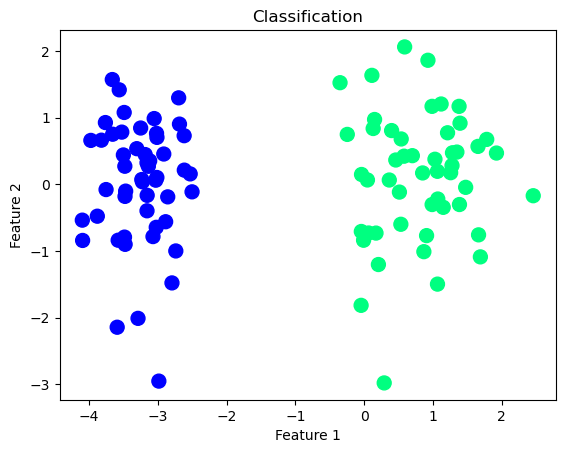

In [4]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0],X[:,1], c=y, cmap='winter',  s=100)

plt.title("Classification")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show();

**Training Algorithm using Gradient Descent**

<font face = "Courier New" color=magenta size=5>
$\large \hspace{7cm} \vec{w}_{new} = \vec{w}_{old} - \eta \frac{1}{n} \sum_{i=1}^n (\hat{y_i} - y_i)\vec{x}$</font>


In [5]:
def gradient_descent(X,y):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    epochs = 10000
    for i in range(epochs):
        y_hat = sigmoid(np.dot(X, weights))
        weights = weights - lr * (1/X.shape[0]) *  np.dot( (y_hat - y), X)
    return weights[0],weights[1:]

```
def perceptron(X,y): 
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    epochs = 10000
    for i in range(epochs):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j], weights) )
        weights = weights + lr*(y[j]-y_hat) * X[j]
    return weights[0],weights[1:]
```

In [6]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [7]:
bias , weights = gradient_descent(X, y)
print("𝑤0: ", bias)
print("w1 and w2: ", weights)

𝑤0:  4.929952752929981
w1 and w2:  [4.21457057 0.16023185]


**Visualize Result**
- $Ax+By+C=0$
- Slope $= -\large \frac{A}{B}$
- y-intercept $= -\large \frac{C}{B}$

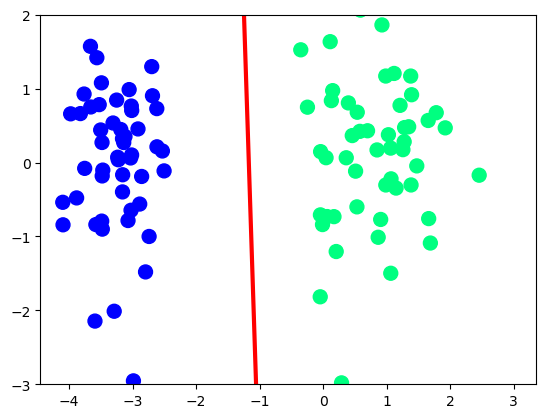

In [8]:
m = -(weights[0]/weights[1])
b = -(bias/weights[1])

x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

plt.plot(x_input, y_input, color='red', linewidth=3)
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter',  s=100)
plt.ylim(-3,2)
plt.show();

## Comparing Results with Scikit-Learn's Logistic Regression Model

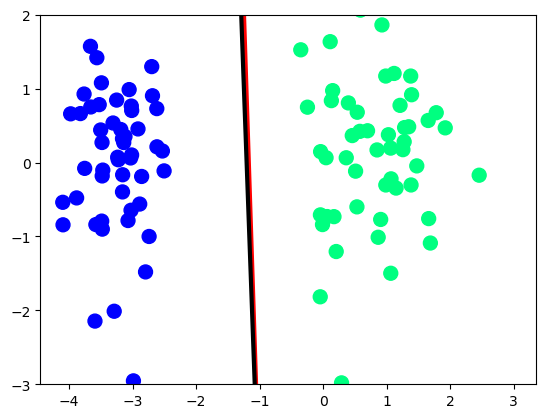

In [9]:
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings("ignore")

model = LogisticRegression(penalty='none',solver='sag')
model.fit(X, y)

m = -(model.coef_[0][0]/model.coef_[0][1])
b = -(model.intercept_/model.coef_[0][1])

x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

plt.plot(x_input,  y_input,  color='red',   linewidth=3)
plt.plot(x_input1, y_input1, color='black', linewidth=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.ylim(-3,2)
plt.show();

**Visualize Decision Boundry using mlxtend Library:**

In [ ]:
# https://rasbt.github.io/mlxtend/
#import sys
#!{sys.executable} -m pip install mlxtend --upgrade --no-deps

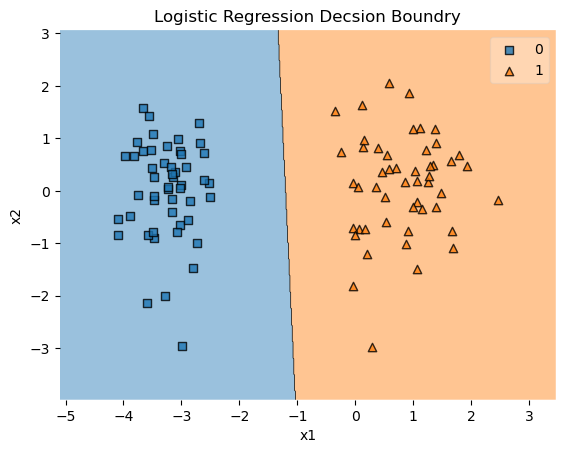

In [10]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X=X, y=y, clf=model)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic Regression Decsion Boundry')
plt.show();

**Plot Sigmoid:**

In [ ]:
# plot sigmoid curve using a example
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

x = np.arange(-10,11)
sigmoid = 1/(1+np.exp(-x))
plt.plot(x,sigmoid, marker='o')
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.grid(True)
plt.show()
df = pd.DataFrame(data = {"z":x, "Sigmoid(z)":sigmoid})
df[0:21:2]

**Plot Derivative of Sigmoid:**

In [ ]:
deri = (1/(1+np.exp(-x)))*(1- 1/(1+np.exp(-x)))
plt.title("Derivative of Sigmoid Function")
plt.plot(x,deri, marker='o')
plt.xlabel("x")
plt.ylabel("sigmoid(x)'")
plt.grid(True)
plt.ylim(0,1)
plt.show()